In [1]:
%%capture
!pip install snowflake-connector-python
!pip install snowflake-snowpark-python
!pip install snowflake-ml-python

### Show Info Warehouse

In [2]:
# Snowpark for Python
from snowflake.snowpark.session import Session
from snowflake.snowpark.functions import month,year,col,sum
from snowflake.snowpark.version import VERSION
from snowflake.snowpark.functions import month,year,col,sum,regexp_replace, col, when
from snowflake.snowpark.functions import col, dense_rank
from snowflake.snowpark.window import Window
# Misc
from datetime import timedelta
import json
import logging
logger = logging.getLogger("snowflake.snowpark.session")
logger.setLevel(logging.ERROR)
# connection parameter
# just account name and user/pwd

# connection_param = {
#     "ACCOUNT":"cy32145.europe-west4.gcp",
#     "USER":"minhdat1",
#     "PASSWORD":"minhdaT1",
#     "DATABASE" : "STAGING",
#     "SCHEMA": "PUBLIC",
#     "WAREHOUSE": "IMPORT_WH"
# }


connection_param = {
    'user':'trucnmt',
    'password':'Thanhtruc28!',
    'account':'WK90181.ap-southeast-1',
    'warehouse':'ETL_WH',
    'database':'STAGING',
    'schema':'CLEAN',
    'role': 'TRANSFORM_ROLE'
}

# creating a session object
session = Session.builder.configs(connection_param).create()

# print values from session object to test
print("\n\t Current Account Name: ",session.get_current_account())
print("\t Current Database Name: ",session.get_current_database())
print("\t Current Schema Name: ",session.get_current_schema())
print("\t Current Role Name: ",session.get_current_role())
print("\t Current Warehouse Name: ",session.get_current_warehouse())
print("\t Fully Qualified Schema Name: ",session.get_fully_qualified_current_schema(),"\n")

print("Session Object Type:", type(session))



	 Current Account Name:  "WK90181"
	 Current Database Name:  "STAGING"
	 Current Schema Name:  "CLEAN"
	 Current Role Name:  "TRANSFORM_ROLE"
	 Current Warehouse Name:  "ETL_WH"
	 Fully Qualified Schema Name:  "STAGING"."CLEAN" 

Session Object Type: <class 'snowflake.snowpark.session.Session'>


### Use 4 tab info of customer for loan approval prediction problem

In [3]:
trans_df = session.table('C_TRANSACTION')
trans_df.show()

loan_df = session.table('LOAN')
loan_df.show()

account_df = session.table('ACCOUNT')
account_df.show()

order_df = session.table('C_ORDER')
order_df.show()

print(f'Transaction count: {trans_df.count()}')
print(f'Loan count: {loan_df.count()}')
print(f'Account count: {account_df.count()}')
print(f'Order count: {order_df.count()}')

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"TRANS_ID"  |"ACCOUNT_ID"  |"TRANS_TYPE"  |"OPERATION_TYPE"  |"TRANS_AMOUNT"  |"TRANS_BALANCE"  |"TRANS_K_SYMBOL"   |"TRANS_BANK"  |"TRANS_ACCOUNT"  |"TRANS_YEAR"  |"TRANS_MONTH"  |"TRANS_DAY"  |"TRANS_HOUR"  |"TRANS_MIN"  |"TRANS_SEC"  |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|T03645508   |A00003489     |Credit        |NULL              |169.3           |35976.7          |Interest Credited  |NULL          |NA               |2017          |11             |30           |14            |41           |29           |
|T03645876   |A00003502     |Credit     

In [5]:
joined_df = loan_df.join(trans_df, on = 'account_id', how = 'inner').join(order_df, on = 'account_id', how = 'inner')
joined_df = joined_df.withColumn(
    "loan_status",
    when(col("loan_status").isin("C", "A"), 0).otherwise(1)
)
joined_df.show(25)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"ACCOUNT_ID"  |"LOAN_ID"  |"LOAN_DURATION"  |"LOAN_PAYMENTS"  |"LOAN_YEAR"  |"LOAN_MONTH"  |"LOAN_DAY"  |"LOAN_AMOUNT"  |"DISTRICT_ID"  |"LOAN_PURPOSE"      |"TRANS_ID"  |"TRANS_TYPE"  |"OPERATION_TYPE"  |"TRANS_AMOUNT"  |"TRANS_BALANCE"  |"TRANS_K_SYMBOL"      |"TRANS_BANK"  |"TRANS_ACCOUNT"  |"TRANS_YEAR"  |"TRANS_MONTH"  |"TRANS_DAY"  |"TRANS_HOUR"  |"TRANS_MIN"  |"TRANS_SEC"  |"ORDER_ID"  |"ORDER_BANK_TO"  |"ORDER_ACCOUNT_TO"  |"ORDER_AMOUNT"  |"ORDER_K_SYMBOL"   |"LOAN_STATUS"  |
------------------

In [7]:
joined_df.count()

447041

In [ ]:
joined_df.filter(col("loan_status") == 1).show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"ACCOUNT_ID"  |"LOAN_ID"  |"LOAN_DURATION"  |"LOAN_PAYMENTS"  |"LOAN_YEAR"  |"LOAN_MONTH"  |"LOAN_DAY"  |"LOAN_AMOUNT"  |"DISTRICT_ID"  |"LOAN_PURPOSE"  |"TRANS_ID"  |"TRANS_TYPE"  |"OPERATION_TYPE"  |"TRANS_AMOUNT"  |"TRANS_BALANCE"  |"TRANS_K_SYMBOL"      |"TRANS_BANK"  |"TRANS_ACCOUNT"  |"TRANS_YEAR"  |"TRANS_MONTH"  |"TRANS_DAY"  |"TRANS_HOUR"  |"TRANS_MIN"  |"TRANS_SEC"  |"ORDER_ID"  |"ORDER_BANK_TO"  |"ORDER_ACCOUNT_TO"  |"ORDER_AMOUNT"  |"ORDER_K_SYMBOL"   |"LOAN_STATUS"  |
--------------------------

In [11]:
categorical_columns = ['loan_purpose', 'trans_type', 'OPERATION_TYPE', 'trans_k_symbol', 'trans_bank', 'order_k_symbol', 'order_bank_to']
for column in categorical_columns:
    window_spec = Window.order_by(col(column))
    joined_df = joined_df.with_column(f"{column}_idx", dense_rank().over(window_spec).cast("float"))


In [12]:
joined_df.show()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"ACCOUNT_ID"  |"LOAN_ID"  |"LOAN_DURATION"  |"LOAN_PAYMENTS"  |"LOAN_YEAR"  |"LOAN_MONTH"  |"LOAN_DAY"  |"LOAN_AMOUNT"  |"DISTRICT_ID"  |"LOAN_PURPOSE"      |"TRANS_ID"  |"TRANS_TYPE"  |"OPERATION_TYPE"              |"TRANS_AMOUNT"  |"TRANS_BALANCE"  |"TRANS_K_SYMBOL"   |"TRANS_BANK"   |"TRANS_ACCOUNT"  |"TRANS_YEAR"  |"TRANS_MONTH"  |"TRANS_DAY" 

In [13]:
joined_df.printSchema()

root
 |-- "ACCOUNT_ID": StringType(20) (nullable = True)
 |-- "LOAN_ID": StringType(20) (nullable = True)
 |-- "LOAN_DURATION": LongType() (nullable = True)
 |-- "LOAN_PAYMENTS": LongType() (nullable = True)
 |-- "LOAN_YEAR": LongType() (nullable = True)
 |-- "LOAN_MONTH": LongType() (nullable = True)
 |-- "LOAN_DAY": LongType() (nullable = True)
 |-- "LOAN_AMOUNT": LongType() (nullable = True)
 |-- "DISTRICT_ID": LongType() (nullable = True)
 |-- "LOAN_PURPOSE": StringType(20) (nullable = True)
 |-- "TRANS_ID": StringType(16777216) (nullable = True)
 |-- "TRANS_TYPE": StringType(50) (nullable = True)
 |-- "OPERATION_TYPE": StringType(16777216) (nullable = True)
 |-- "TRANS_AMOUNT": DoubleType() (nullable = True)
 |-- "TRANS_BALANCE": DoubleType() (nullable = True)
 |-- "TRANS_K_SYMBOL": StringType(16777216) (nullable = True)
 |-- "TRANS_BANK": StringType(16777216) (nullable = True)
 |-- "TRANS_ACCOUNT": StringType(16777216) (nullable = True)
 |-- "TRANS_YEAR": LongType() (nullable = T

In [20]:
joined_df_pandas = joined_df.to_pandas()
numeric_cols=joined_df_pandas.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['LOAN_DURATION', 'LOAN_PAYMENTS', 'LOAN_YEAR', 'LOAN_MONTH', 'LOAN_DAY',
       'LOAN_AMOUNT', 'DISTRICT_ID', 'TRANS_AMOUNT', 'TRANS_BALANCE',
       'TRANS_YEAR', 'TRANS_MONTH', 'TRANS_DAY', 'ORDER_ID',
       'ORDER_ACCOUNT_TO', 'ORDER_AMOUNT', 'LOAN_STATUS', 'LOAN_PURPOSE_IDX',
       'TRANS_TYPE_IDX', 'OPERATION_TYPE_IDX', 'TRANS_K_SYMBOL_IDX',
       'TRANS_BANK_IDX', 'ORDER_K_SYMBOL_IDX', 'ORDER_BANK_TO_IDX'],
      dtype='object')

### Check Label Imbalance

In [17]:
from snowflake.snowpark.functions import col, count


In [18]:
label_col = "LOAN_STATUS"

label_distribution = joined_df.group_by(label_col).agg(count("*").alias("count"))
label_distribution.show()

---------------------------
|"LOAN_STATUS"  |"COUNT"  |
---------------------------
|0              |407278   |
|1              |39763    |
---------------------------



Count of loan_status 1: 39763
Count of loan_status 0: 407278


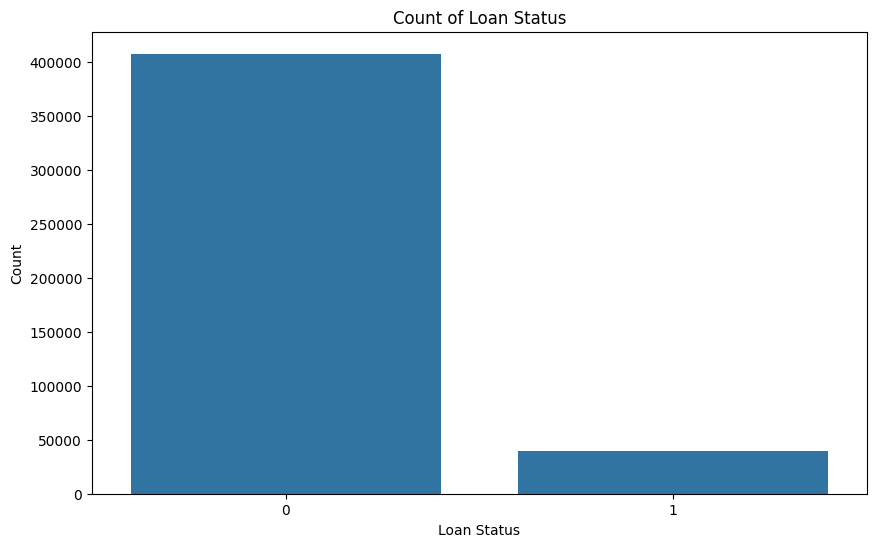

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
count_loan_status_1 = joined_df.filter(col("loan_status") == 1).count()
count_loan_status_0 = joined_df.filter(col("loan_status") == 0).count()

print(f'Count of loan_status 1: {count_loan_status_1}')
print(f'Count of loan_status 0: {count_loan_status_0}')

joined_pd_df = joined_df.to_pandas()

plt.figure(figsize=(10, 6))
sns.countplot(x='LOAN_STATUS', data=joined_pd_df)
plt.title('Count of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

### Imbalance

In [19]:
max_count = label_distribution.select("count").agg({"count": "max"}).collect()[0][0]
schema = joined_df.schema

balanced_df = session.create_dataframe([], schema=schema)

for row in label_distribution.collect():
    label = row[label_col]
    count1 = row["COUNT"]

    subset_df = joined_df.filter(col(label_col) == label)

    if count1 < max_count:
        additional_count = max_count - count1
        oversampled_df = subset_df
        while oversampled_df.count() < additional_count:
            oversampled_df = oversampled_df.union_all(subset_df)

        oversampled_df = oversampled_df.limit(additional_count)
        balanced_subset = subset_df.union_all(oversampled_df)
    else:
        balanced_subset = subset_df

    balanced_df = balanced_df.union_all(balanced_subset)

# Kiểm tra lại phân phối nhãn sau khi cân bằng
joined_df = balanced_df
joined_df.group_by(label_col).agg(count("*").alias("count")).show()

---------------------------
|"LOAN_STATUS"  |"COUNT"  |
---------------------------
|1              |407278   |
|0              |407278   |
---------------------------



### Train, Test Split

In [21]:
import pandas as pd
import numpy as np
import random
from snowflake.ml.modeling.xgboost import XGBClassifier
from snowflake.ml.utils.connection_params import SnowflakeLoginOptions
from snowflake.snowpark import Session, DataFrame

from snowflake.ml.modeling.preprocessing import StandardScaler
from snowflake.ml.modeling.impute import SimpleImputer
from snowflake.ml.modeling.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from snowflake.ml.modeling.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

feature_cols = ['LOAN_AMOUNT', 'LOAN_DURATION', 'LOAN_PAYMENTS',
                   'LOAN_YEAR', 'LOAN_MONTH', 'LOAN_DAY',
                   'TRANS_TYPE_IDX', 'OPERATION_TYPE_IDX', 'TRANS_AMOUNT', 'TRANS_BALANCE',
                   'TRANS_K_SYMBOL_IDX', 'TRANS_BANK_IDX', 'ORDER_BANK_TO_IDX', 'ORDER_K_SYMBOL_IDX']
feature_cols_1 = ['LOAN_AMOUNT', 'LOAN_DURATION', 'LOAN_PAYMENTS',
                   'LOAN_YEAR', 'LOAN_MONTH', 'LOAN_DAY',
                   'TRANS_TYPE_IDX', 'OPERATION_TYPE_IDX', 'TRANS_AMOUNT', 'TRANS_BALANCE',
                   'TRANS_K_SYMBOL_IDX', 'TRANS_BANK_IDX', 'ORDER_BANK_TO_IDX', 'ORDER_K_SYMBOL_IDX','LOAN_STATUS']
label_col = ["LOAN_STATUS"]



train_ratio = 0.7

joined_df_pandas['random_val'] = [random.random() for _ in range(len(joined_df_pandas))]

# Chia dữ liệu thành tập huấn luyện và kiểm tra
train_df = joined_df_pandas[joined_df_pandas['random_val'] < train_ratio].reset_index(drop=True)
val_df = joined_df_pandas[joined_df_pandas['random_val'] >= train_ratio].reset_index(drop=True)

# Xóa cột ngẫu nhiên
train_df = train_df.drop(columns=['random_val'])[feature_cols_1]
val_df = val_df.drop(columns=['random_val'])[feature_cols_1]

# Split data into train and validation sets
train_data = session.create_dataframe(train_df.reset_index(drop=True))
val_data = session.create_dataframe(val_df.reset_index(drop=True))



### Snowflake Model Registry

In [ ]:
from snowflake.ml.registry import Registry
reg = Registry(session=session, database_name="STAGING", schema_name="CLEAN")


def registry_model(model):
    reg.log_model(model,
                  model_name=f"{type(model).__name__}",
                  version_name="v2_fulldata",
                  conda_dependencies=["scikit-learn"],
                  comment="OK",
                  metrics={"score": model.score(val_data)},
                  sample_input_data=joined_df_pandas[feature_cols],
                  options={'relax_version': False})
    print("Model registered")
    print("Saved model")




### Train Model with Snowpark ML and Save to Model Registry in Snowflake Data Warehouse

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from snowflake.ml.modeling.ensemble import RandomForestClassifier, GradientBoostingClassifier
from snowflake.ml.modeling.tree import DecisionTreeClassifier
from snowflake.ml.modeling.linear_model import RidgeClassifier
from snowflake.ml.modeling.neighbors import KNeighborsClassifier
from snowflake.ml.modeling.xgboost import XGBClassifier
from snowflake.ml.modeling.pipeline import Pipeline
from snowflake.ml.modeling.linear_model import LogisticRegression
from snowflake.ml.modeling.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from snowflake.snowpark import Session
from snowflake.snowpark.functions import col
import warnings

# Assuming session and data are already defined
feature_cols = ['LOAN_AMOUNT', 'LOAN_DURATION', 'LOAN_PAYMENTS',
                'LOAN_YEAR', 'LOAN_MONTH', 'LOAN_DAY',
                'TRANS_TYPE_IDX', 'OPERATION_TYPE_IDX', 'TRANS_AMOUNT', 'TRANS_BALANCE',
                'TRANS_K_SYMBOL_IDX', 'TRANS_BANK_IDX', 'ORDER_BANK_TO_IDX', 'ORDER_K_SYMBOL_IDX']

label_col = "LOAN_STATUS"
# Create a list of classifiers with regularization and parameter tuning
classifiers = [
    LogisticRegression(input_cols=feature_cols,label_cols=label_col,max_iter=10000, C=0.01),
    DecisionTreeClassifier(input_cols=feature_cols,label_cols=label_col,max_depth=10, min_samples_split=20, min_samples_leaf=5),
    RandomForestClassifier(input_cols=feature_cols,label_cols=label_col,n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=5, max_features='sqrt'),
    RidgeClassifier(input_cols=feature_cols,label_cols=label_col,alpha=0.01),
    GradientBoostingClassifier(input_cols=feature_cols,label_cols=label_col,learning_rate=0.1),
    KNeighborsClassifier(input_cols=feature_cols,label_cols=label_col,n_neighbors=4)
]





results=[]
def train_and_evaluate(model, train_data, val_data):
    try:

        warnings.filterwarnings("ignore", category=UserWarning)
        model.fit(train_data)

        predictions = model.predict(val_data)

        accuracy = accuracy_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"])
        f1_macro = f1_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"], average='macro')
        weightedPrecision = precision_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"], average='weighted')
        weightedRecall = recall_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"], average='weighted')
        macro_precision = precision_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"], average='macro')
        macro_recall = recall_score(df=predictions, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"], average='macro')


        # Print evaluation metrics
        print(f"Model: {type(model).__name__}")
        print(f"Accuracy = {accuracy:.4f}")
        print(f"F1-macro score = {f1_macro:.4f}")
        print(f"Weighted Precision = {weightedPrecision:.4f}")
        print(f"Weighted Recall = {weightedRecall:.4f}")
        print(f"Macro Precision = {macro_precision:.4f}")
        print(f"Macro Recall = {macro_recall:.4f}")

        predictions_pd=predictions.to_pandas()[['LOAN_STATUS','OUTPUT_LOAN_STATUS']]

        results.append(predictions_pd)
        registry_model(model)




    except Exception as e:
        print(f"Model {type(model).__name__} failed with error: {e}")
# Train and evaluate each model
# models=["lr_model","dt_model","rf_model","rc_model","gb_model","kn_model"]
for classifier in classifiers:
    train_and_evaluate(classifier, train_data, val_data)

Model: LogisticRegression
Accuracy = 0.6730
F1-macro score = 0.6726
Weighted Precision = 0.6736
Weighted Recall = 0.6730
Macro Precision = 0.6736
Macro Recall = 0.6730
Model LogisticRegression failed with error: (0000) Model LogisticRegression version v2_fulldata already existed.
Model: DecisionTreeClassifier
Accuracy = 0.9543
F1-macro score = 0.9542
Weighted Precision = 0.9565
Weighted Recall = 0.9543
Macro Precision = 0.9565
Macro Recall = 0.9543
Model DecisionTreeClassifier failed with error: (0000) Model DecisionTreeClassifier version v2_fulldata already existed.
Model: RandomForestClassifier
Accuracy = 0.9924
F1-macro score = 0.9924
Weighted Precision = 0.9924
Weighted Recall = 0.9924
Macro Precision = 0.9924
Macro Recall = 0.9924
Model RandomForestClassifier failed with error: (0000) Model RandomForestClassifier version v2_fulldata already existed.
Model: RidgeClassifier
Accuracy = 0.7114
F1-macro score = 0.7113
Weighted Precision = 0.7116
Weighted Recall = 0.7114
Macro Precision

Model: KNeighborsClassifier
Accuracy = 0.9881
F1-macro score = 0.9881
Weighted Precision = 0.9884
Weighted Recall = 0.9881
Macro Precision = 0.9884
Macro Recall = 0.9882
Model registered
Saved model


### Consfusion Metric

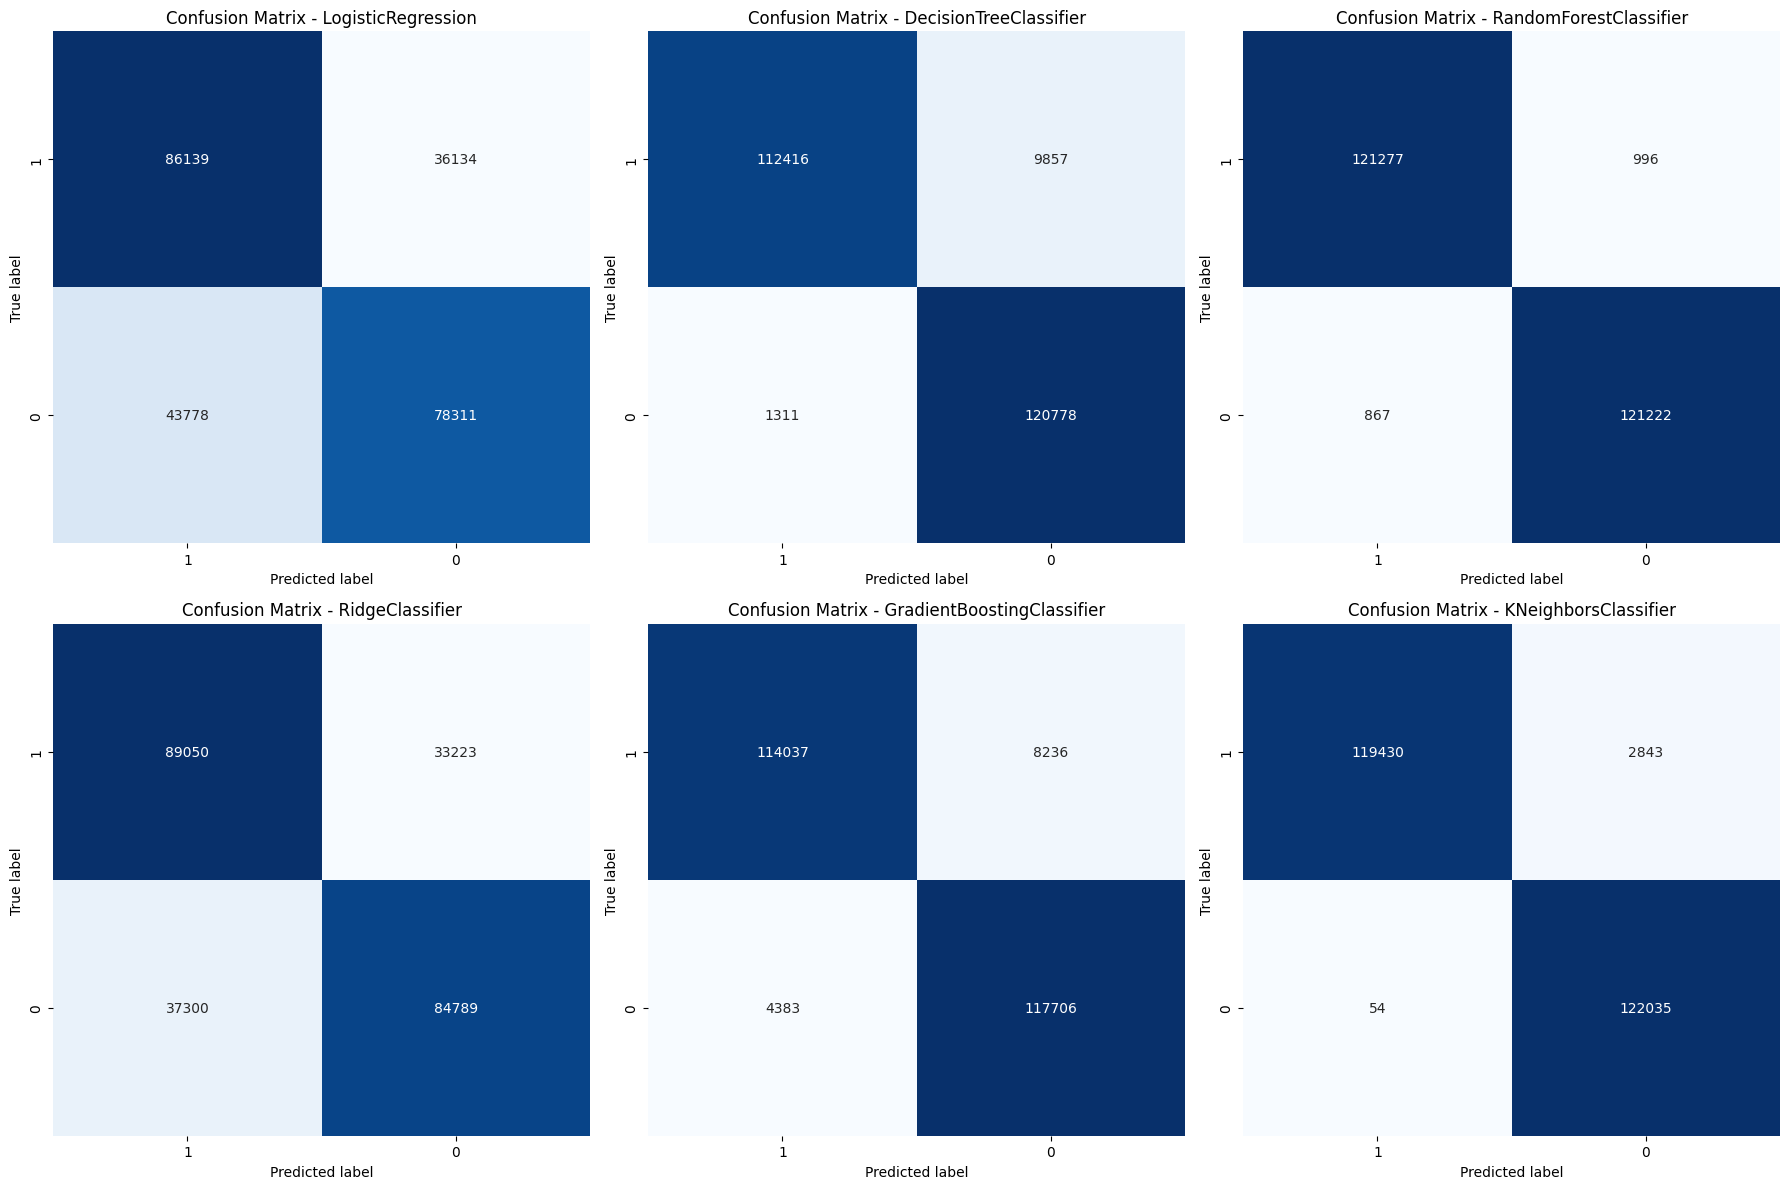

In [ ]:
unique_values = train_data.select(col(label_col)).distinct().collect()
unique_values = [row[0] for row in unique_values]

plt.figure(figsize=(18, 12))

for idx, (result, model) in enumerate(zip(results, classifiers), 1):
    plt.subplot(2, 3, idx)

    conf_matrix = pd.crosstab(result['LOAN_STATUS'], result['OUTPUT_LOAN_STATUS'],
                              rownames=['True label'], colnames=['Predicted label'])

    # Vẽ heatmap
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=unique_values,
                yticklabels=unique_values)

    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {type(model).__name__}')

# Hiển thị tất cả các figure
plt.tight_layout()
plt.show()

### Registry Model Inference

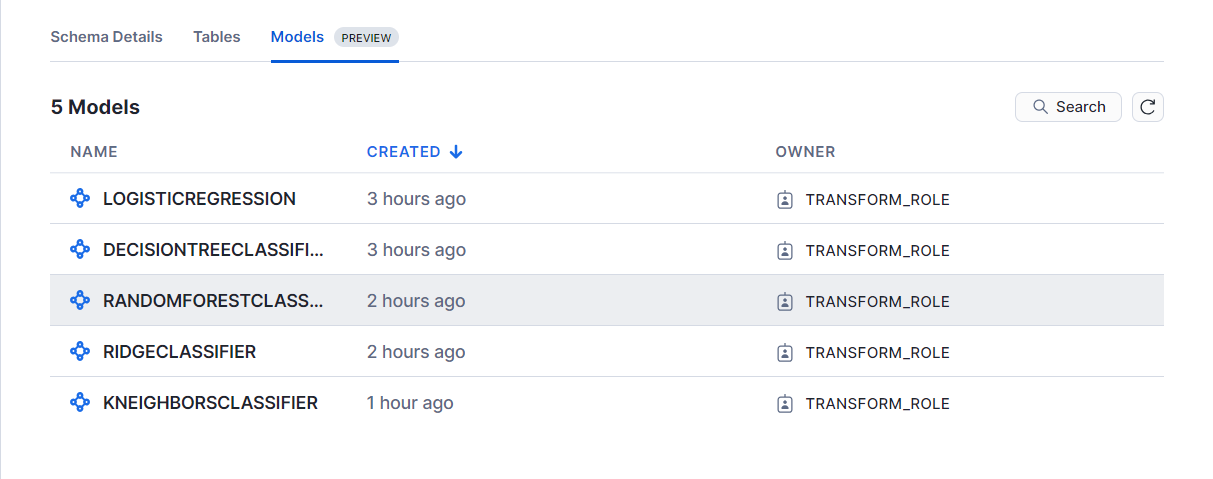

In [ ]:
mv=reg.get_model("KNeighborsClassifier")

In [ ]:
mv.show_versions()


,created_on,name,aliases,comment,database_name,schema_name,module_name,is_default_version,functions,metadata,user_data
0,2024-07-01 11:34:19.864000-07:00,V1,"[""DEFAULT"",""FIRST""]",OK,STAGING,CLEAN,DECISIONTREECLASSIFIER,true,"[""PREDICT_PROBA"",""PREDICT"",""PREDICT_LOG_PROBA""]","{""metrics"": {""score"": 0.9859154929577465}, ""sn...",{}
1,2024-07-01 12:53:14.506000-07:00,V2_FULLDATA,"[""LAST""]",OK,STAGING,CLEAN,DECISIONTREECLASSIFIER,false,"[""PREDICT_PROBA"",""PREDICT"",""PREDICT_LOG_PROBA""]","{""metrics"": {""score"": 0.9333308455854915}, ""sn...",{}


In [ ]:
clf = mv.version("V2_FULLDATA").load()

/usr/local/lib/python3.10/dist-packages/snowflake/ml/_internal/telemetry.py:368: RuntimeWarning: Loading model requires to have the exact the same environment as the one when logging the model, otherwise, the model might be not functional or some other problems might occur.
  res = func(*args, **kwargs)


In [ ]:
v1_test_df=clf.predict(val_data)

In [ ]:
accuracy_=accuracy_score(df=v1_test_df, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"])
print(accuracy_)

0.641434


In [ ]:
models=["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier","RidgeClassifier","KNeighborsClassifier"]

In [ ]:
for model in models:
    mv=reg.get_model(model)
    print(f"{model}:")
    clf = mv.version("V2_FULLDATA").load()
    v1_test_df=clf.predict(val_data)
    accuracy_=accuracy_score(df=v1_test_df, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"])
    f1_score_=f1_score(df=v1_test_df, y_true_col_names=["LOAN_STATUS"], y_pred_col_names=["OUTPUT_LOAN_STATUS"])
    print(f"accuracy:{accuracy_}")
    print(f"f1-score:{f1_score_}")

LogisticRegression:


/usr/local/lib/python3.10/dist-packages/snowflake/ml/_internal/telemetry.py:368: RuntimeWarning: Loading model requires to have the exact the same environment as the one when logging the model, otherwise, the model might be not functional or some other problems might occur.
  res = func(*args, **kwargs)


----------------------------------------
|"LOAN_STATUS"  |"OUTPUT_LOAN_STATUS"  |
----------------------------------------
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
----------------------------------------

accuracy:0.529006
f1-score:0.1124092882647356
DecisionTreeClassifier:


/usr/local/lib/python3.10/dist-packages/snowflake/ml/_internal/telemetry.py:368: RuntimeWarning: Loading model requires to have the exact the same environment as the one when logging the model, otherwise, the model might be not functional or some other problems might occur.
  res = func(*args, **kwargs)


----------------------------------------
|"LOAN_STATUS"  |"OUTPUT_LOAN_STATUS"  |
----------------------------------------
|1              |0                     |
|1              |0                     |
|1              |1                     |
|1              |0                     |
|1              |0                     |
|1              |1                     |
|1              |0                     |
|1              |0                     |
|1              |1                     |
|1              |0                     |
----------------------------------------

accuracy:0.641434
f1-score:0.4432442049613664
RandomForestClassifier:


...

----------------------------------------
|"LOAN_STATUS"  |"OUTPUT_LOAN_STATUS"  |
----------------------------------------
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
----------------------------------------

accuracy:0.544094
f1-score:0.16102358646865683
RidgeClassifier:


/usr/local/lib/python3.10/dist-packages/snowflake/ml/_internal/telemetry.py:368: RuntimeWarning: Loading model requires to have the exact the same environment as the one when logging the model, otherwise, the model might be not functional or some other problems might occur.
  res = func(*args, **kwargs)


----------------------------------------
|"LOAN_STATUS"  |"OUTPUT_LOAN_STATUS"  |
----------------------------------------
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
|1              |0                     |
----------------------------------------

accuracy:0.500376
f1-score:0.0
KNeighborsClassifier:


/usr/local/lib/python3.10/dist-packages/snowflake/ml/_internal/telemetry.py:368: RuntimeWarning: Loading model requires to have the exact the same environment as the one when logging the model, otherwise, the model might be not functional or some other problems might occur.
  res = func(*args, **kwargs)


----------------------------------------
|"LOAN_STATUS"  |"OUTPUT_LOAN_STATUS"  |
----------------------------------------
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
|1              |1                     |
----------------------------------------

accuracy:0.988145
f1-score:0.988269687853033
